In [1]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as fy
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [3]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'

In [4]:
data = pd.read_csv(url)

In [6]:
data.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [7]:
dataset = data['Temp'].dropna().values.reshape(-1,1)

In [8]:
scalar = MinMaxScaler(feature_range=(0,1))
scaled_data = scalar.fit_transform(dataset)

In [9]:
X = []
Y = []

In [10]:
for i in range(60,len(scaled_data)):
    X.append(scaled_data[i-60:i,0])
    Y.append(scaled_data[i,0])

In [11]:
X, Y = np.array(X).reshape(-1,60,1), np.array(Y)

In [12]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:] 
Y_train, Y_test = Y[:split], Y[split:]

In [14]:
model = Sequential([
    LSTM(50, input_shape = (60,1)),
    Dense(1)
])

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [16]:
model.fit(X_train, Y_train, epochs=5,batch_size=32, validation_data=(X_train, Y_train))

Epoch 1/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - loss: 0.0174 - val_loss: 0.0109
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0109 - val_loss: 0.0107
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0106 - val_loss: 0.0105
Epoch 4/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0104 - val_loss: 0.0102
Epoch 5/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0103 - val_loss: 0.0100


In [17]:
pred = scalar.inverse_transform(model.predict(X_test))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [18]:
actual = scalar.inverse_transform(Y_test.reshape(-1,1))

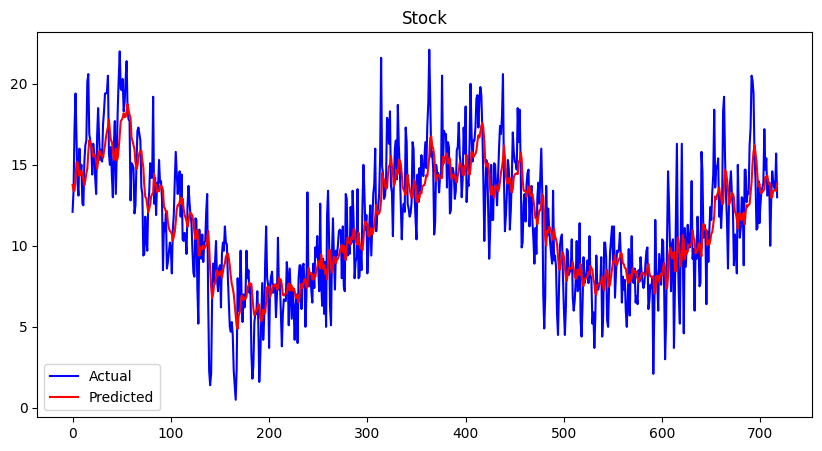

In [19]:
plt.figure(figsize=(10,5))
plt.plot(actual,color='blue',label = 'Actual')
plt.plot(pred,color = 'red', label = 'Predicted')
plt.title('Stock')
plt.legend()
plt.show()

In [20]:
actual

array([[12.1],
       [13.4],
       [17.3],
       [19.4],
       [16.6],
       [13.9],
       [13.1],
       [16. ],
       [14.5],
       [15. ],
       [12.6],
       [12.5],
       [15.2],
       [16.2],
       [16.5],
       [20.1],
       [20.6],
       [16.9],
       [16.5],
       [16.1],
       [14.4],
       [16.3],
       [15.7],
       [14.2],
       [13.2],
       [16.8],
       [18.5],
       [16.7],
       [15.3],
       [15.9],
       [15.2],
       [17.5],
       [18.3],
       [19.4],
       [19.4],
       [19.5],
       [20.5],
       [15.7],
       [15. ],
       [16.1],
       [14.3],
       [13. ],
       [16.2],
       [17.7],
       [13.2],
       [15.8],
       [18.5],
       [20.4],
       [22. ],
       [19.7],
       [19.6],
       [20.3],
       [18.3],
       [18.9],
       [20.3],
       [21.4],
       [18.3],
       [17.8],
       [17.7],
       [12.8],
       [15.1],
       [15. ],
       [14.8],
       [12. ],
       [12.5],
       [15. ],
       [17

In [21]:
pred

array([[13.759322 ],
       [13.382221 ],
       [13.412216 ],
       [14.208697 ],
       [15.139952 ],
       [15.174143 ],
       [14.716171 ],
       [14.301962 ],
       [14.637996 ],
       [14.490093 ],
       [14.531899 ],
       [14.046104 ],
       [13.735438 ],
       [14.068778 ],
       [14.447504 ],
       [14.761362 ],
       [15.75884  ],
       [16.510878 ],
       [16.258295 ],
       [16.121302 ],
       [15.965758 ],
       [15.512513 ],
       [15.646323 ],
       [15.5627165],
       [15.200902 ],
       [14.767952 ],
       [15.237129 ],
       [15.838035 ],
       [15.840423 ],
       [15.598295 ],
       [15.594874 ],
       [15.425938 ],
       [15.815524 ],
       [16.20685  ],
       [16.713081 ],
       [17.05899  ],
       [17.3467   ],
       [17.78991  ],
       [17.042257 ],
       [16.519333 ],
       [16.40562  ],
       [15.9002495],
       [15.305348 ],
       [15.579506 ],
       [15.994843 ],
       [15.280321 ],
       [15.438703 ],
       [16.04